# Раздел ВКР: система метрик и расчёт показателей

Настоящий ноутбук сочетает **текст методического раздела** (его можно копировать в диссертацию) и **исполняемый код**, который загружает артефакты стенда и формирует сводные таблицы. В текст ВКР обычно переносят **результаты таблиц и формулы**; листинг кода не обязателен.

**Границы исследования:** не используются CPU/RAM в браузере; не количественно оцениваются негативные сценарии ошибок.

**Данные:** `e2e-results/rpc-*.json`, `e2e-results/wallet-mock-*.json`, `bundle-analysis.json` (для критерия размера кода в MCDA используются **library bundles** — сопоставимый объём только Web3-стека без React/UI, см. `docs/BundleSize.md`), файл сообщества `analysis/community_metrics.json` (шаблон — `community_metrics.example.json`). При отсутствии `e2e-results` подставляются фикстуры из `analysis/fixtures/`.


In [1]:
# Зависимости (выполнить один раз на ядро)
%pip install -q "pandas>=2.0" "numpy>=1.24" "ahpy" "pymcdm" "scipy>=1.10" "matplotlib>=3.8"


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Конфигурация и пути к файлам

Корень проекта определяется по наличию `bundle-analysis.json`. Список библиотек и сопоставление с секциями файла задаются ниже: для размера кода в MCDA читаются **library bundles** (`dist-lib-*` или `libraryBundles`), а не полный production-бандл приложения.


In [14]:
from __future__ import annotations

import json
import warnings
from datetime import date, datetime
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

try:
    from IPython import get_ipython

    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

import matplotlib.pyplot as plt

# --- настройки ---
LIBRARIES: list[str] = ["ethers", "viem"]
# Плоские ключи из bundle-analysis.json (library-only, см. npm run run-bundle-analysis)
BUNDLE_KEY_BY_LIB: dict[str, str] = {"ethers": "dist-lib-ethers", "viem": "dist-lib-viem"}
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#FF6200", "#0F4FA8", "#3BDA00"])
# Дата «наблюдения» для расчёта стажа с первого релиза (замените на дату снятия метрик в ВКР)
REFERENCE_DATE: date = date.today()

def project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "bundle-analysis.json").exists():
        return cwd
    if (cwd.parent / "bundle-analysis.json").exists():
        return cwd.parent
    return cwd


ROOT = project_root()
E2E_DIR = ROOT / "e2e-results"
FIXTURE_DIR = ROOT / "analysis" / "fixtures"
BUNDLE_PATH = ROOT / "bundle-analysis.json"

try:
    from IPython.display import display
except ImportError:
    display = print


def resolve_results(name: str) -> Path:
    p = E2E_DIR / name
    if p.exists():
        return p
    fp = FIXTURE_DIR / name
    if fp.exists():
        warnings.warn(f"Используется фикстура: {fp}", stacklevel=2)
        return fp
    return p


def load_json(path: Path) -> dict[str, Any]:
    with path.open(encoding="utf-8") as f:
        return json.load(f)


def bundle_metrics_for_lib(bundle: dict[str, Any], lib: str) -> dict[str, Any] | None:
    """Метрики размера для lib: сначала плоский ключ BUNDLE_KEY_BY_LIB, иначе libraryBundles[lib]."""
    key = BUNDLE_KEY_BY_LIB.get(lib)
    if key and isinstance(bundle.get(key), dict):
        return bundle[key]
    nested = bundle.get("libraryBundles")
    if isinstance(nested, dict) and isinstance(nested.get(lib), dict):
        return nested[lib]
    return None


def plot_rpc_latency_by_operation(df_ops: pd.DataFrame) -> None:
    """Ось X — RPC-методы, ось Y — время (мс); столбцы каждой библиотеки своим цветом."""
    if df_ops.empty or "mean_ms" not in df_ops.columns:
        return
    d = df_ops.dropna(subset=["mean_ms"]).copy()
    if d.empty:
        return
    id_col = "operation_id"
    if id_col not in d.columns or d[id_col].isna().all() or (d[id_col].astype(str).str.strip() == "").all():
        id_col = "name"
    pivot = d.pivot_table(index=id_col, columns="lib", values="mean_ms", aggfunc="first")
    # pivot = pivot.sort_index()
    pivot = pivot.sort_index(key=lambda idx: idx.astype(str))
    fig_w = max(9.0, 0.55 * len(pivot) + 4)
    fig_h = max(4.5, min(14, 2.5 + 0.12 * len(pivot)))
    ax = pivot.plot(
        kind="bar",
        figsize=(fig_w, fig_h),
        width=0.82,
        edgecolor="0.35",
        linewidth=0.4,
    )
    ax.set_xlabel("RPC-метод")
    ax.set_ylabel("Время, мс (среднее по серии)")
    ax.set_title("Задержки по операциям (без кошелька)")
    ax.legend(title="Библиотека")
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


def plot_rpc_aggregates(df_agg: pd.DataFrame) -> None:
    if df_agg.empty:
        return
    cols = ["rpc_mean_of_means_ms", "rpc_median_of_p50_ms"]
    if not all(c in df_agg.columns for c in cols):
        return
    labels = {
        "rpc_mean_of_means_ms": "Среднее из mean\nпо операциям",
        "rpc_median_of_p50_ms": "Медиана p50\nпо операциям",
    }
    m = df_agg.melt(id_vars=["lib"], value_vars=cols, var_name="metric", value_name="value")
    m = m.dropna(subset=["value"])
    if m.empty:
        return
    pivot = m.pivot(index="metric", columns="lib", values="value")
    pivot.index = [labels.get(str(i), str(i)) for i in pivot.index]
    ax = pivot.plot(kind="bar", figsize=(7, 4), width=0.75, edgecolor="0.35", linewidth=0.4)
    ax.set_ylabel("Время, мс")
    ax.set_xlabel("Агрегат")
    ax.set_title("Сводные показатели RPC")
    ax.legend(title="Библиотека")
    plt.tight_layout()
    plt.show()


def plot_wallet_latency(df_wallet: pd.DataFrame) -> None:
    if df_wallet.empty:
        return
    value_cols = [c for c in df_wallet.columns if c.startswith("wallet_") and c.endswith("_ms")]
    if not value_cols:
        return
    m = df_wallet.melt(id_vars=["lib"], value_vars=value_cols, var_name="stage", value_name="ms")
    m = m.dropna(subset=["ms"])
    if m.empty:
        return
    m["stage"] = (
        m["stage"].str.replace("wallet_", "", regex=False).str.replace("_mean_ms", "", regex=False).str.replace("_ms", "", regex=False)
    )
    pivot = m.pivot(index="stage", columns="lib", values="ms")
    ax = pivot.plot(kind="bar", figsize=(8, 4.2), width=0.78, edgecolor="0.35", linewidth=0.4)
    ax.set_ylabel("Время, мс")
    ax.set_xlabel("Этап (mock wallet)")
    ax.set_title("Задержки операций с кошельком")
    ax.legend(title="Библиотека")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


def plot_bundle_sizes(df_bundle: pd.DataFrame) -> None:
    if df_bundle.empty:
        return
    cols = ["bundle_raw_bytes", "bundle_gzip_bytes", "bundle_brotli_bytes"]
    if not all(c in df_bundle.columns for c in cols):
        return
    labels = {"bundle_raw_bytes": "raw", "bundle_gzip_bytes": "gzip", "bundle_brotli_bytes": "brotli"}
    m = df_bundle.melt(id_vars=["lib"], value_vars=cols, var_name="fmt", value_name="bytes")
    m = m.dropna(subset=["bytes"])
    if m.empty:
        return
    m["fmt"] = m["fmt"].map(labels)
    pivot = m.pivot(index="fmt", columns="lib", values="bytes")
    order = [x for x in ["raw", "gzip", "brotli"] if x in pivot.index]
    pivot = pivot.reindex(order)
    ax = pivot.plot(kind="bar", figsize=(7, 4), width=0.75, edgecolor="0.35", linewidth=0.4)
    ax.set_ylabel("Размер, байты")
    ax.set_xlabel("Формат")
    ax.set_title("Размер бандла библиотеки (library bundle)")
    ax.legend(title="Библиотека")
    plt.tight_layout()
    plt.show()


def plot_community_metrics(df_c: pd.DataFrame) -> None:
    num_cols = [
        "github_stars",
        "github_forks",
        "github_watchers",
        "npm_weekly_downloads",
        "npm_dependents",
        "npm_dependencies",
        "years_since_first_release",
    ]
    present = [c for c in num_cols if c in df_c.columns]
    if not present or df_c.empty:
        return
    ncols = 2
    nrows = (len(present) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 2.8 * nrows), squeeze=False)
    short = {
        "github_stars": "GitHub stars",
        "github_forks": "GitHub forks",
        "github_watchers": "GitHub watchers",
        "npm_weekly_downloads": "NPM downloads/wk",
        "npm_dependents": "NPM dependents",
        "npm_dependencies": "NPM dependencies",
        "years_since_first_release": "Стаж (лет)",
    }
    for i, col in enumerate(present):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        sub = df_c[["lib", col]].dropna()
        if sub.empty:
            ax.set_visible(False)
            continue
        libs = sub["lib"].astype(str).tolist()
        vals = sub[col].astype(float).tolist()
        ax.bar(libs, vals, color=plt.cm.tab10(np.linspace(0, 0.85, len(libs))))
        ax.set_title(short.get(col, col))
    for j in range(len(present), nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].set_visible(False)
    fig.suptitle("Метрики сообщества по библиотекам", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()


print("ROOT =", ROOT)
print("REFERENCE_DATE =", REFERENCE_DATE)


ROOT = D:\ITMOMagistracy\VKR\playground_v2
REFERENCE_DATE = 2026-03-28


## 1. Публичные RPC-операции (без кошелька)

**Назначение.** Оценить задержку типичных вызовов к узлу сети через абстракцию библиотеки при отсутствии пользовательского кошелька: одинаковый стенд, RPC и набор методов (`RPC_OPERATIONS` в коде проекта).

**Методика.** Для каждой операции выполняется серия замеров; в JSON сохраняются `stats.mean`, `stats.p50`, `stats.p95` и др. **Агрегаты в ноутбуке:** `rpc_mean_of_means_ms` — среднее арифметическое значений `mean` по всем операциям библиотеки; `rpc_median_of_p50_ms` — медиана значений `p50` по операциям (если поле заполнено).

**Воспроизводимость.** Фиксируются версии библиотеки и браузера, URL RPC, число повторов. Файлы: `e2e-results/rpc-<lib>.json`.

**Интерпретация в MCDA:** минимизация времени отклика.

Ниже — таблица по операциям, столбчатая диаграмма (по оси X — RPC-методы, по Y — среднее время, мс; библиотеки — разными цветами) и строка агрегатов с отдельной диаграммой.


,lib,operation_id,name,mean_ms,p50_ms,p95_ms,count
0,ethers,web3_clientVersion,web3_clientVersion,18.104,17.0,25.3,100
1,ethers,web3_sha3,web3_sha3,0.111,0.0,0.9,100
2,ethers,net_version,net_version,18.714,18.4,25.2,100
3,ethers,net_peerCount,net_peerCount,0.000,0.0,0.0,0
4,ethers,net_listening,net_listening,17.698,16.4,25.1,100
5,ethers,eth_chainId,eth_chainId,17.997,17.2,24.3,100
6,ethers,eth_syncing,eth_syncing,19.501,19.2,26.5,100
7,ethers,eth_blockNumber,eth_blockNumber,0.175,0.0,0.1,100
8,ethers,eth_getBalance,eth_getBalance,18.346,17.7,24.9,100
9,ethers,eth_getCode,eth_getCode,18.908,17.9,26.2,100


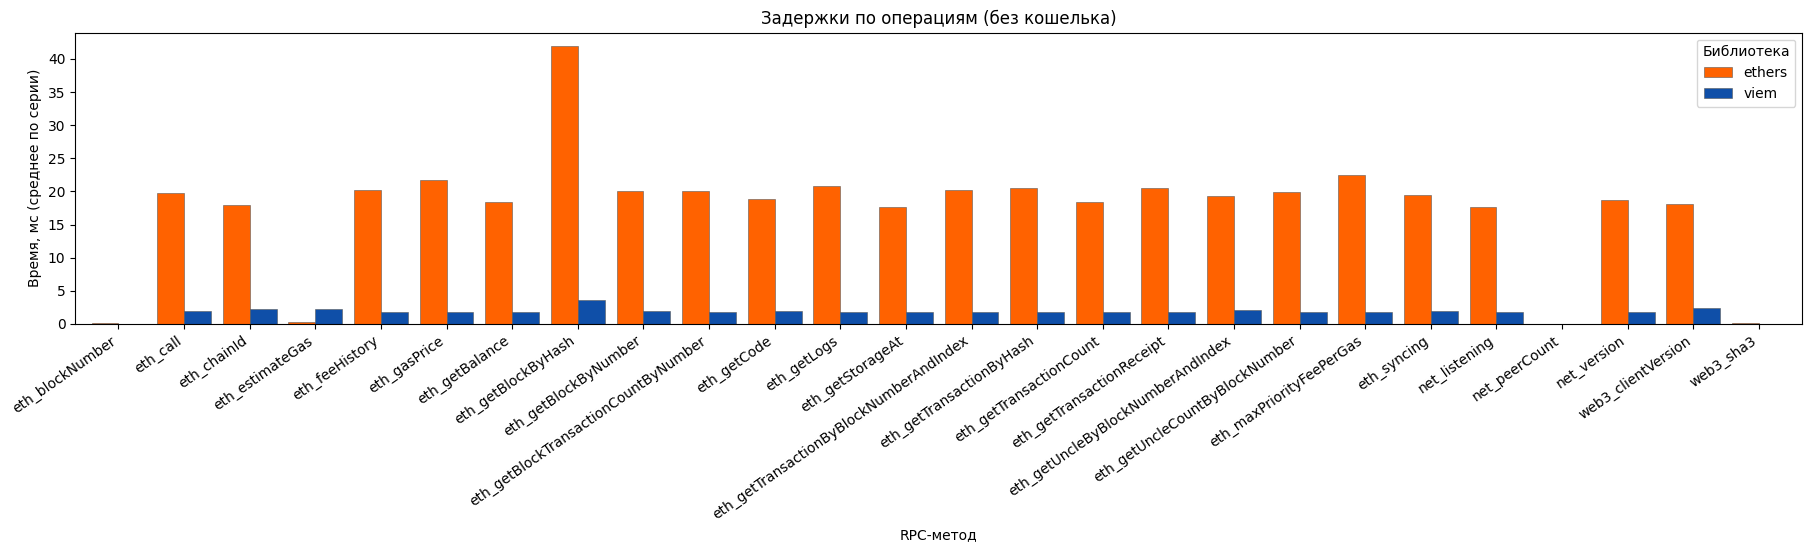

,lib,rpc_mean_of_means_ms,rpc_median_of_p50_ms,rpc_operations_count
0,ethers,17.437308,19.1,26
1,viem,1.747346,1.8,26


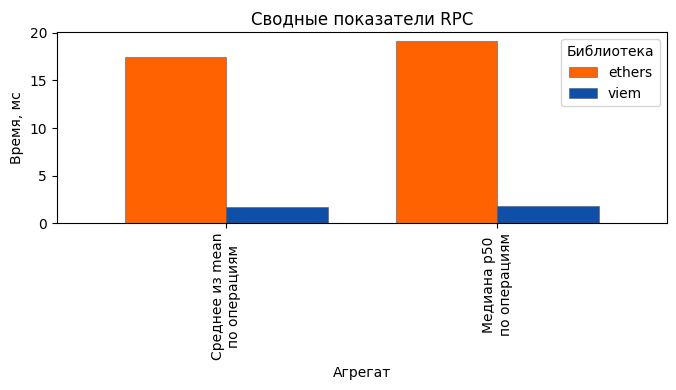

In [15]:
def rpc_rows_from_file(path: Path, lib: str) -> list[dict[str, Any]]:
    if not path.exists():
        return []
    data = load_json(path)
    rows = []
    for op in data.get("operations") or []:
        st = op.get("stats") or {}
        rows.append(
            {
                "lib": lib,
                "operation_id": op.get("operationId", ""),
                "name": op.get("name", ""),
                "mean_ms": st.get("mean"),
                "p50_ms": st.get("p50"),
                "p95_ms": st.get("p95"),
                "count": st.get("count"),
            }
        )
    return rows


all_rpc: list[dict[str, Any]] = []
for lib in LIBRARIES:
    all_rpc.extend(rpc_rows_from_file(resolve_results(f"rpc-{lib}.json"), lib))

df_rpc_ops = pd.DataFrame(all_rpc)
if len(df_rpc_ops):
    display(df_rpc_ops)
    plot_rpc_latency_by_operation(df_rpc_ops)
else:
    print("Нет данных rpc-*.json — прогоните E2E или положите фикстуры в analysis/fixtures/")

# Агрегаты по библиотеке (для сводной таблицы и ВКР)
agg_rows = []
for lib in LIBRARIES:
    sub = df_rpc_ops[df_rpc_ops["lib"] == lib] if len(df_rpc_ops) else pd.DataFrame()
    if len(sub) and sub["mean_ms"].notna().any():
        agg_rows.append(
            {
                "lib": lib,
                "rpc_mean_of_means_ms": float(sub["mean_ms"].mean()),
                "rpc_median_of_p50_ms": float(sub["p50_ms"].median()) if sub["p50_ms"].notna().any() else np.nan,
                "rpc_operations_count": int(len(sub)),
            }
        )
    else:
        agg_rows.append(
            {
                "lib": lib,
                "rpc_mean_of_means_ms": np.nan,
                "rpc_median_of_p50_ms": np.nan,
                "rpc_operations_count": 0,
            }
        )

df_rpc_agg = pd.DataFrame(agg_rows)
display(df_rpc_agg)
plot_rpc_aggregates(df_rpc_agg)


## 2. Операции с кошельком (mock wallet / E2E)

**Назначение.** Задержки сценариев с провайдером EIP-1193: подключение, подписание транзакции, отправка в сеть.

**Методика.** В JSON стенда разделены холодное подключение (`coldConnectMs`), тёплое (`warmConnect.stats.mean`), подписание (`sign.stats.mean`), отправка (`send.stats.mean`). Для сопоставимости условий используется mock wallet в E2E; прогон с реальным MetaMask — отдельный режим, который следует описать во введении.

**Интерпретация в MCDA:** по каждому показателю — минимизация.

Источник: `e2e-results/wallet-mock-<lib>.json`.


,lib,wallet_cold_connect_ms,wallet_warm_mean_ms,wallet_sign_mean_ms,wallet_send_mean_ms
0,ethers,4.4,1.585859,3.313,3.117
1,viem,3.8,1.931313,3.086,3.118


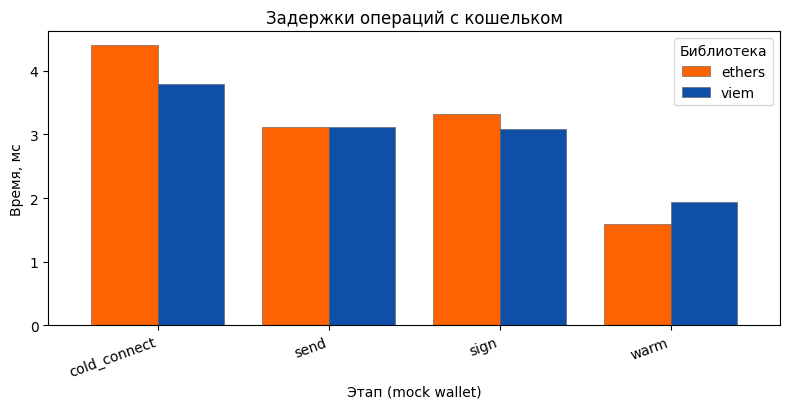

In [16]:
def load_wallet_mock(path: Path) -> dict[str, float] | None:
    if not path.exists():
        return None
    w = load_json(path)
    wc = w.get("warmConnect") or {}
    sg = w.get("sign") or {}
    sn = w.get("send") or {}
    return {
        "wallet_cold_connect_ms": float(w.get("coldConnectMs") or np.nan),
        "wallet_warm_mean_ms": float((wc.get("stats") or {}).get("mean") or np.nan),
        "wallet_sign_mean_ms": float((sg.get("stats") or {}).get("mean") or np.nan),
        "wallet_send_mean_ms": float((sn.get("stats") or {}).get("mean") or np.nan),
    }


w_rows = []
for lib in LIBRARIES:
    p = resolve_results(f"wallet-mock-{lib}.json")
    m = load_wallet_mock(p)
    if m:
        w_rows.append({"lib": lib, **m})
    else:
        w_rows.append(
            {
                "lib": lib,
                "wallet_cold_connect_ms": np.nan,
                "wallet_warm_mean_ms": np.nan,
                "wallet_sign_mean_ms": np.nan,
                "wallet_send_mean_ms": np.nan,
            }
        )

df_wallet = pd.DataFrame(w_rows)
display(df_wallet)
plot_wallet_latency(df_wallet)


## 3. Размер бандла библиотеки (library bundles)

**Назначение.** Сопоставимый объём JS **только Web3-стека** (те же value-импорты, что в адаптерах стенда), без React и без кода приложения. В `bundle-analysis.json` это секции `libraryBundles` и плоские ключи `dist-lib-ethers` / `dist-lib-viem` (команда `npm run run-bundle-analysis`).

**Методика.** Сумма по всем `.js` в `assets/` соответствующей lib-сборки; в таблицу попадают `totalRaw`, `totalGzip`, `totalBrotli` (байты). Полный бандл приложения (`dist-ethers` / `dist-viem`) в MCDA **не используется**, чтобы критерий отражал именно библиотеку при фиксированном сценарии импортов.

**Интерпретация в MCDA:** минимизация (как и раньше — усреднение gzip и brotli в блоке 6).


,lib,bundle_raw_bytes,bundle_gzip_bytes,bundle_brotli_bytes
0,ethers,261247.0,96898.0,84237.0
1,viem,279703.0,86744.0,67533.0


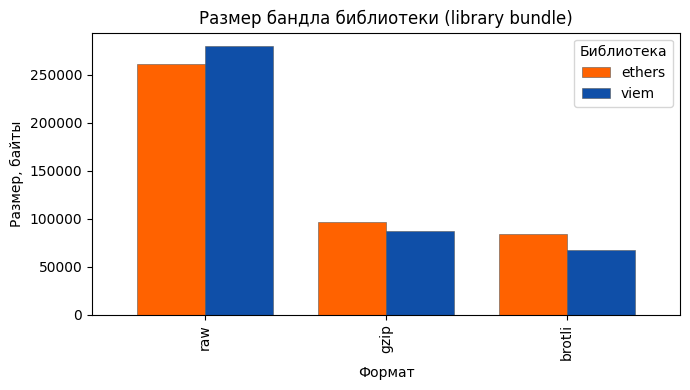

In [17]:
b_rows = []
if BUNDLE_PATH.exists():
    bundle = load_json(BUNDLE_PATH)
    for lib in LIBRARIES:
        b = bundle_metrics_for_lib(bundle, lib)
        if b is not None:
            b_rows.append(
                {
                    "lib": lib,
                    "bundle_raw_bytes": float(b.get("totalRaw", np.nan)),
                    "bundle_gzip_bytes": float(b.get("totalGzip", np.nan)),
                    "bundle_brotli_bytes": float(b.get("totalBrotli", np.nan)),
                }
            )
        else:
            b_rows.append({"lib": lib, "bundle_raw_bytes": np.nan, "bundle_gzip_bytes": np.nan, "bundle_brotli_bytes": np.nan})
else:
    warnings.warn(f"Нет файла {BUNDLE_PATH}", stacklevel=2)
    b_rows = [{"lib": lib, "bundle_raw_bytes": np.nan, "bundle_gzip_bytes": np.nan, "bundle_brotli_bytes": np.nan} for lib in LIBRARIES]

df_bundle = pd.DataFrame(b_rows)
display(df_bundle)
plot_bundle_sizes(df_bundle)


## 4. Метрики сообщества (GitHub и NPM)

Значения задаются в **`analysis/community_metrics.json`** (скопируйте из `community_metrics.example.json`). Поля:

| Поле | Смысл | Тип в MCDA |
|------|-------|------------|
| `github_stars`, `github_forks`, `github_watchers` | активность на GitHub | максимизация |
| `npm_weekly_downloads`, `npm_dependents` | спрос и встраиваемость в npm | максимизация |
| `npm_dependencies` | число прямых зависимостей пакета | по согласованию (часто минимизация как «компактность графа») |
| `first_release_date` | дата первой публикации в npm (ISO `YYYY-MM-DD`) | переводится в **стаж в годах** до `REFERENCE_DATE`; направление — по смыслу работы (часто максимизация стажа) |

Ниже приведены **определения** показателей; затем — загрузка JSON, расчёт стажа `years_since_first_release`, таблица и корреляционная матрица (для анализа избыточности критериев в AHP).

### 4.1. GitHub Stars
Количество «звёзд» репозитория; прокси интереса к проекту. В MCDA обычно **максимизация**.

### 4.2. GitHub Forks
Число форков; вовлечённость разработчиков. **Максимизация**.

### 4.3. GitHub Watchers
Число наблюдателей за репозиторием. **Максимизация**.

### 4.4. NPM downloads (last week)
Скачивания пакета за последнюю неделю. **Максимизация**; фиксируйте дату снятия (`_collected_at` в JSON).

### 4.5. NPM dependents
Число публичных пакетов, зависящих от данного. **Максимизация**.

### 4.6. NPM dependencies
Число прямых зависимостей в публикуемом пакете; интерпретация **минимизация vs максимизация** должна быть согласована в тексте ВКР (компактность графа vs функциональность).

### 4.7. First release date
Дата первого релиза (ISO). В ноутбуке переводится в **стаж в годах** до `REFERENCE_DATE`; направление предпочтения задаётся во введении (**максимизация** стажа или иная логика).


C:\Users\pravo\AppData\Local\Temp\ipykernel_22152\3341324752.py:32: UserWarning: Используется community_metrics.example.json — замените на свой community_metrics.json
  comm = load_community()


,lib,github_stars,github_forks,github_watchers,npm_weekly_downloads,npm_dependents,npm_dependencies,first_release_date,years_since_first_release
0,ethers,7000,1200,180,1200000,45000,12,2015-10-01,10.488706
1,viem,8500,900,120,800000,38000,8,2023-02-28,3.077344


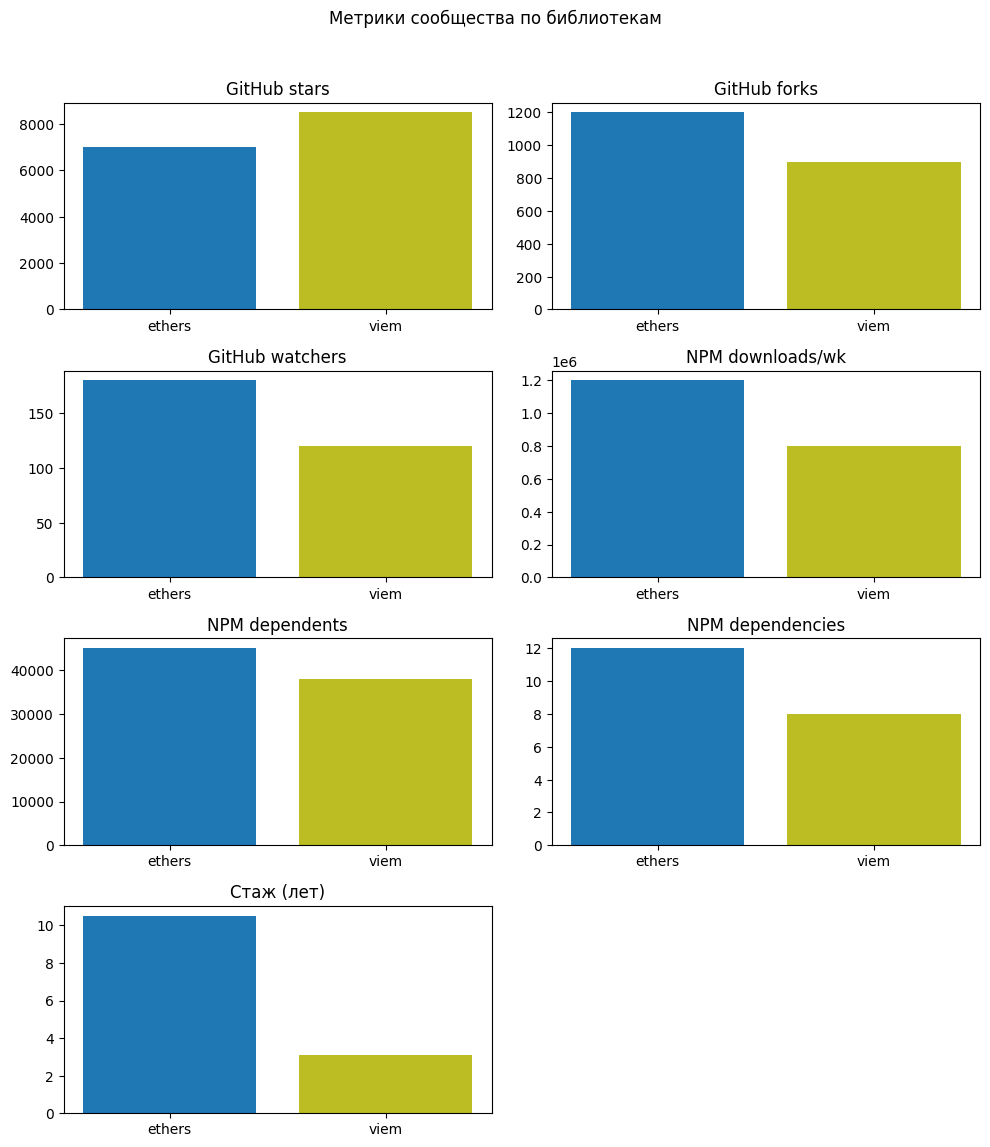

,github_stars,github_forks,github_watchers,npm_weekly_downloads,npm_dependents,npm_dependencies,years_since_first_release
github_stars,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
github_forks,-1.0,1.0,1.0,1.0,1.0,1.0,1.0
github_watchers,-1.0,1.0,1.0,1.0,1.0,1.0,1.0
npm_weekly_downloads,-1.0,1.0,1.0,1.0,1.0,1.0,1.0
npm_dependents,-1.0,1.0,1.0,1.0,1.0,1.0,1.0
npm_dependencies,-1.0,1.0,1.0,1.0,1.0,1.0,1.0
years_since_first_release,-1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [18]:
def load_community() -> dict[str, dict[str, Any]]:
    path = ROOT / "analysis" / "community_metrics.json"
    ex = ROOT / "analysis" / "community_metrics.example.json"
    if path.exists():
        raw = load_json(path)
    elif ex.exists():
        warnings.warn("Используется community_metrics.example.json — замените на свой community_metrics.json", stacklevel=2)
        raw = load_json(ex)
    else:
        raw = {}
    return {k: v for k, v in raw.items() if not str(k).startswith("_")}


def parse_iso_date(s: Any) -> date | None:
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return None
    if isinstance(s, datetime):
        return s.date()
    if isinstance(s, date):
        return s
    text = str(s).strip()[:10]
    try:
        return date.fromisoformat(text)
    except ValueError:
        return None


def years_between(start: date, end: date) -> float:
    return (end - start).days / 365.25


comm = load_community()
c_rows = []
for lib in LIBRARIES:
    row = comm.get(lib, {})
    fr = parse_iso_date(row.get("first_release_date"))
    ysr = years_between(fr, REFERENCE_DATE) if fr else np.nan
    c_rows.append(
        {
            "lib": lib,
            "github_stars": row.get("github_stars", np.nan),
            "github_forks": row.get("github_forks", np.nan),
            "github_watchers": row.get("github_watchers", np.nan),
            "npm_weekly_downloads": row.get("npm_weekly_downloads", np.nan),
            "npm_dependents": row.get("npm_dependents", np.nan),
            "npm_dependencies": row.get("npm_dependencies", np.nan),
            "first_release_date": row.get("first_release_date"),
            "years_since_first_release": ysr,
        }
    )

df_community = pd.DataFrame(c_rows)
display(df_community)
plot_community_metrics(df_community)

# Корреляции (помогает увидеть избыточность критериев)
num_cols = [
    "github_stars",
    "github_forks",
    "github_watchers",
    "npm_weekly_downloads",
    "npm_dependents",
    "npm_dependencies",
    "years_since_first_release",
]
sub = df_community[num_cols].apply(pd.to_numeric, errors="coerce")
if sub.notna().sum().sum() > len(num_cols):
    display(sub.corr(numeric_only=True).round(3))
else:
    print("Недостаточно чисел для корреляционной матрицы — заполните community_metrics.json")


## 5. Сводная таблица метрик (для таблицы в ВКР и для MCDA)

Объединяются блоки 1–4. При необходимости экспортируйте в CSV и подставьте значения в `mcda_comparison.ipynb` или вручную в матрицу решений.


In [19]:
# Слияние по столбцу lib
m = df_rpc_agg.merge(df_wallet, on="lib", how="outer").merge(df_bundle, on="lib", how="outer").merge(df_community, on="lib", how="outer")

# Удобный порядок столбцов
preferred = [
    "lib",
    "rpc_mean_of_means_ms",
    "rpc_median_of_p50_ms",
    "rpc_operations_count",
    "wallet_cold_connect_ms",
    "wallet_warm_mean_ms",
    "wallet_sign_mean_ms",
    "wallet_send_mean_ms",
    "bundle_gzip_bytes",
    "bundle_brotli_bytes",
    "bundle_raw_bytes",
    "github_stars",
    "github_forks",
    "github_watchers",
    "npm_weekly_downloads",
    "npm_dependents",
    "npm_dependencies",
    "first_release_date",
    "years_since_first_release",
]
cols = [c for c in preferred if c in m.columns]
df_summary = m[cols].copy()
display(df_summary)

# Экспорт (раскомментируйте при необходимости)
# out = ROOT / "analysis" / "metrics_summary_export.csv"
# df_summary.to_csv(out, index=False)
# print("Saved", out)


,lib,rpc_mean_of_means_ms,rpc_median_of_p50_ms,rpc_operations_count,wallet_cold_connect_ms,wallet_warm_mean_ms,wallet_sign_mean_ms,wallet_send_mean_ms,bundle_gzip_bytes,bundle_brotli_bytes,bundle_raw_bytes,github_stars,github_forks,github_watchers,npm_weekly_downloads,npm_dependents,npm_dependencies,first_release_date,years_since_first_release
0,ethers,17.437308,19.1,26,4.4,1.585859,3.313,3.117,96898.0,84237.0,261247.0,7000,1200,180,1200000,45000,12,2015-10-01,10.488706
1,viem,1.747346,1.8,26,3.8,1.931313,3.086,3.118,86744.0,67533.0,279703.0,8500,900,120,800000,38000,8,2023-02-28,3.077344


## 6. Многокритериальный анализ: AHP + TOPSIS

Для выбора наиболее подходящей библиотеки применён многокритериальный анализ (MCDA) в связке **AHP + TOPSIS**:

- **AHP** используется для задания **весов критериев** на основе парных сравнений (шкала Саати) и проверки согласованности.
- **TOPSIS** выполняет **ранжирование альтернатив** (библиотек) по близости к идеальному решению с учётом весов критериев.

В этой версии используются только следующие группы метрик (без CPU/RAM и без негативных сценариев ошибок):

1. `RPC` без кошелька: общее время отклика типичных публичных операций (`rpc_mean_of_means_ms`) — **минимизация**.
2. `RPC` с кошельком: интегральная задержка операций, выполняемых через кошелёк (усреднение `wallet_warm_mean_ms`, `wallet_sign_mean_ms`, `wallet_send_mean_ms`) — **минимизация**.
3. Размер **бандла библиотеки** (library bundles: без React/UI, сопоставимый импортный граф; усреднение `bundle_gzip_bytes` и `bundle_brotli_bytes`) — **минимизация**.
4. Активность сообщества: составной индекс `community_index`, который агрегирует GitHub и NPM метрики и стаж существования (`years_since_first_release`). Для `npm_dependencies` принято допущение, что **меньше зависимостей лучше**.

Результатом вычислений будет таблица с весами критериев (AHP) и итоговым рейтингом библиотек (TOPSIS).

In [20]:
# --- Подготовка матрицы критериев (строго по выбранным группам метрик) ---

WALLET_LATENCY_COLS = ['wallet_warm_mean_ms', 'wallet_sign_mean_ms', 'wallet_send_mean_ms']
BUNDLE_COLS = ['bundle_gzip_bytes', 'bundle_brotli_bytes']

# Компоненты индекса сообщества (все нормализуются min-max; затем усредняются)
COMMUNITY_BENEFIT_COLS = [
    'github_stars',
    'github_forks',
    'github_watchers',
    'npm_weekly_downloads',
    'npm_dependents',
    'years_since_first_release',
]
COMMUNITY_COST_COL = 'npm_dependencies'  # меньше зависимостей лучше


def minmax_norm(s: pd.Series) -> pd.Series:
    lo, hi = pd.to_numeric(s, errors='coerce').min(), pd.to_numeric(s, errors='coerce').max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi == lo:
        # если все значения одинаковые (или NaN), вклад критерия нейтрален
        return pd.Series(0.5, index=s.index)
    return (s - lo) / (hi - lo)


# Критерии MCDA
mcda_df = pd.DataFrame({'lib': df_summary['lib'].copy()})
mcda_df['rpc_no_wallet_latency_ms'] = pd.to_numeric(df_summary['rpc_mean_of_means_ms'], errors='coerce')
mcda_df['rpc_with_wallet_latency_ms'] = df_summary[WALLET_LATENCY_COLS].apply(pd.to_numeric, errors='coerce').mean(axis=1, skipna=True)

# Усредняем gzip и brotli как приближение к доставляемому размеру
mcda_df['bundle_size_for_mcda_bytes'] = df_summary[BUNDLE_COLS].apply(pd.to_numeric, errors='coerce').mean(axis=1, skipna=True)

# Индекс сообщества: нормализованные benefit и преобразованный cost
community_norm_benefit = [minmax_norm(df_summary[c]) for c in COMMUNITY_BENEFIT_COLS]
community_norm_cost = 1.0 - minmax_norm(df_summary[COMMUNITY_COST_COL])
community_components = community_norm_benefit + [community_norm_cost]
mcda_df['community_index'] = pd.concat(community_components, axis=1).mean(axis=1)

# Список критериев и их тип для TOPSIS: 1 = максимум лучше, -1 = минимум лучше
CRITERIA_COLS = ['rpc_no_wallet_latency_ms', 'rpc_with_wallet_latency_ms', 'bundle_size_for_mcda_bytes', 'community_index']
TYPES = np.array([-1, -1, -1, 1], dtype=int)

display(mcda_df)


,lib,rpc_no_wallet_latency_ms,rpc_with_wallet_latency_ms,bundle_size_for_mcda_bytes,community_index
0,ethers,17.437308,2.671953,90567.5,0.714286
1,viem,1.747346,2.711771,77138.5,0.285714


In [21]:
# --- AHP: веса критериев ---

import ahpy

n = len(CRITERIA_COLS)

# Пояснение: матрица rough задаёт парные суждения важности критериев.
# Здесь выбрана типовая логика: задержки (RPC) важнее размера бандла библиотеки, а он важнее метрик сообщества.
# При необходимости замените значения в rough на ваши экспертные суждения.
rough = np.array([
    [1,     1,     3,     5],
    [1,     1,     3,     5],
    [1/3,   1/3,   1,     2],
    [1/5,   1/5,   1/2,   1],
], dtype=float)

comparisons: dict[tuple[str, str], float] = {}
for i in range(n):
    for j in range(i + 1, n):
        comparisons[(CRITERIA_COLS[i], CRITERIA_COLS[j])] = float(rough[i, j])

cmp = ahpy.Compare(name='criteria', comparisons=comparisons, precision=4, random_index='saaty')
weights_dict = cmp.target_weights

print('AHP: CR =', cmp.consistency_ratio)
if cmp.consistency_ratio > 0.1:
    warnings.warn('CR > 0.1 — скорректируйте попарные сравнения AHP', stacklevel=2)

weights = np.array([weights_dict[c] for c in CRITERIA_COLS], dtype=float)
weights = weights / weights.sum()

weights_table = pd.DataFrame({'criterion': CRITERIA_COLS, 'weight': weights}).sort_values('weight', ascending=False)
display(weights_table)


AHP: CR = 0.0016


,criterion,weight
0,rpc_no_wallet_latency_ms,0.3936
1,rpc_with_wallet_latency_ms,0.3936
2,bundle_size_for_mcda_bytes,0.1375
3,community_index,0.0753


In [22]:
# --- TOPSIS: ранжирование альтернатив ---

from pymcdm.methods import TOPSIS

X_dec = mcda_df[CRITERIA_COLS].to_numpy(dtype=float)
alts = mcda_df['lib'].to_numpy()

mask = np.isfinite(X_dec).all(axis=1)
if not mask.all():
    warnings.warn('Есть NaN в матрице критериев — соответствующие альтернативы отброшены', stacklevel=2)

X_use = X_dec[mask]
alts_use = alts[mask]

topsis = TOPSIS()
pref = topsis(X_use, weights, TYPES)

# Ранг: 1 — лучший (больше pref)
order = np.argsort(-pref)
rank = np.empty_like(order)
rank[order] = np.arange(1, len(order) + 1)

result = pd.DataFrame({'lib': alts_use, 'topsis_closeness': pref, 'rank': rank}).sort_values('rank')
display(result)

# Для удобства дальнейших вставок в текст
best_lib = result.iloc[0]['lib']
print('TOPSIS: лучшая библиотека =', best_lib)


,lib,topsis_closeness,rank
1,viem,0.509899,1
0,ethers,0.490101,2


TOPSIS: лучшая библиотека = viem


После выполнения ячеек выше таблица `result` содержит итоговый рейтинг библиотек. Для формулировки рекомендаций в ВКР используйте строку с `rank = 1`, а также веса критериев (таблица из AHP), чтобы объяснить, почему выбранная библиотека превосходит альтернативы именно по вашим приоритетам.

---

### Как переносить в текст ВКР

- В **диссертацию** имеет смысл включать **итоговую таблицу** (`df_summary`), результаты **AHP (веса критериев)** и **TOPSIS (ранжирование библиотек)**, а также отдельные формулировки из разделов 1–4 выше и при необходимости **корреляционную матрицу** метрик сообщества.
- **Код** в приложении не обязателен; для формального вида можно описать расчёты словами, например: *среднее время по RPC-операциям вычислялось как среднее арифметическое показателей `mean` по всем операциям стенда для данной библиотеки*; *стаж пакета — как разность между датой наблюдения и датой первого релиза, выраженная в годах*; *оценка библиотек выполнялась по AHP+TOPSIS с предварительной нормализацией и заданием весов критериев*.

При изменении списка библиотек обновите `LIBRARIES`, ключи в `BUNDLE_KEY_BY_LIB` (для новых lib — соответствующие `dist-lib-*` в `bundle-analysis.json` или вложенный `libraryBundles`) и строки в `community_metrics.json`.
